# Hipotézisvizsgálat és A/B tesztelés — worked example

**FONTOS:** minden szám ebben a notebookban szintetikus (kézzel épített), a
gyakorlat kedvéért generált — nem valós Chess.com- vagy más cég adat. Nincs
beolvasott CSV: ez a notebook direkt a `business-case.md`-ben és a
`lesson-plan.md`-ben megadott számokból indul ki.

Két rész:
1. **A "Gyorsított párkeresés" kísérlet** — kétmintás arány-z-teszt
2. **"Nettó konverzió / DAU"** — a Streaks vs. Puzzle v2 összehasonlítás

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

## 1. "Gyorsított párkeresés" — kétmintás arány-z-teszt

**Hipotézis**: a gyorsabb párkeresés-motor növeli a sikeresen elindított
partik arányát azok között, akik elkezdik a párkeresést.

| Csoport | n | Sikeres indítás | p̂ |
|---|---|---|---|
| Control (régi motor) | 40 000 | 36 400 | 91,00% |
| Treatment (gyors motor) | 40 000 | 36 520 | 91,30% |

In [2]:
# Pooled ketmintas aranyteszt. Visszaadja a (diff, pooled_p, se_pool, z, p_two_tailed) otost.
def two_sample_proportion_ztest(n_control, k_control, n_treatment, k_treatment):
    p_c = k_control / n_control
    p_t = k_treatment / n_treatment
    diff = p_t - p_c
    p_pool = (k_control + k_treatment) / (n_control + n_treatment)
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n_control + 1 / n_treatment))
    z = diff / se_pool
    p_two_tailed = 2 * norm.cdf(-abs(z))
    return diff, p_pool, se_pool, z, p_two_tailed


n_c, k_c = 40_000, 36_400
n_t, k_t = 40_000, 36_520

diff, p_pool, se_pool, z, p_value = two_sample_proportion_ztest(n_c, k_c, n_t, k_t)

print(f"p_control     = {k_c/n_c:.4%}")
print(f"p_treatment   = {k_t/n_t:.4%}")
print(f"diff          = {diff:.4%}")
print(f"pooled p      = {p_pool:.4%}")
print(f"SE (pooled)   = {se_pool:.4%}")
print(f"z-score       = {z:.3f}")
print(f"p-value (2t)  = {p_value:.4f}")

p_control     = 91.0000%
p_treatment   = 91.3000%
diff          = 0.3000%
pooled p      = 91.1500%
SE (pooled)   = 0.2008%
z-score       = 1.494
p-value (2t)  = 0.1352


**Értelmezés**: p ≈ 0,135 > 0,05 — **nem utasítjuk el $H_0$-t**.
A megfigyelt +0,30 százalékpontos különbség ennél a mintaméretnél simán lehet
véletlen ingadozás. Ez *nem* azt jelenti, hogy a gyors motor nem segít —
csak azt, hogy ennyi adatból nem tudjuk megkülönböztetni a nullától.

Mielőtt tovább mennénk: pontosan ez az a pillanat, ahol a p-hacking / optional
stopping csábítása jelentkezik — "nézzük meg csak mobilon", "fusson tovább
még egy hétig". Az előadás ezt a kísértést mutatja be élőben; itt csak a
számolást rögzítjük.

## 2. Nettó konverzió / DAU

Két, MÁR lefutott kísérlet. A kérdés: melyik érte el nagyobb, **cégre nézett**
hatást, ha tudjuk, hogy teljesen különböző közönséget értek el?

In [3]:
TOTAL_WEB_DAU = 200_000

experiments = pd.DataFrame(
    [
        {"name": "Streaks", "reach": 200_000, "control_rate": 0.420, "treatment_rate": 0.426},
        {"name": "Puzzle v2", "reach": 20_000, "control_rate": 0.550, "treatment_rate": 0.600},
    ]
)
experiments

,name,reach,control_rate,treatment_rate
0,Streaks,200000,0.42,0.426
1,Puzzle v2,20000,0.55,0.600


In [4]:
# Egy kiserlet cegre nezett, DAU-normalt hatasa:
#   netto_konverzio_per_DAU = (elert letszam * abszolut lift) / teljes DAU
# Hataresetkent: ha reach == total_dau, ez pont visszaadja az abszolut liftet.
def net_conversions_per_dau(reach, control_rate, treatment_rate, total_dau=TOTAL_WEB_DAU):
    absolute_lift = treatment_rate - control_rate
    incremental_users = reach * absolute_lift
    return incremental_users, incremental_users / total_dau


results = []
for _, row in experiments.iterrows():
    incremental_users, net_per_dau = net_conversions_per_dau(
        row["reach"], row["control_rate"], row["treatment_rate"]
    )
    relative_lift = (row["treatment_rate"] - row["control_rate"]) / row["control_rate"]
    results.append(
        {
            "name": row["name"],
            "reach_pct_of_dau": row["reach"] / TOTAL_WEB_DAU,
            "relative_lift": relative_lift,
            "incremental_users_per_day": incremental_users,
            "net_conversions_per_dau": net_per_dau,
        }
    )

results_df = pd.DataFrame(results)
results_df.style.format(
    {
        "reach_pct_of_dau": "{:.0%}",
        "relative_lift": "{:+.1%}",
        "incremental_users_per_day": "{:,.0f}",
        "net_conversions_per_dau": "{:.2%}",
    }
)

,name,reach_pct_of_dau,relative_lift,incremental_users_per_day,net_conversions_per_dau
0,Streaks,100%,+1.4%,"1,200",0.60%
1,Puzzle v2,10%,+9.1%,"1,000",0.50%


**A csattanó**: a `relative_lift` oszlop szerint a Puzzle v2 néz ki jobban
(+9,1% vs. +1,4%) — de a `net_conversions_per_dau` oszlop szerint a **Streaks
nyer** (0,60% vs. 0,50%), mert tízszer annyi embert ér el. Ez a teljes
pointe: a naiv (relatív lift) rangsor és a cégre nézett (DAU-normált) rangsor
**megfordulhat** — és a döntő mindig az utóbbi kell legyen, mert az egyetlen
kísérletek közötti összehasonlítható mérce.

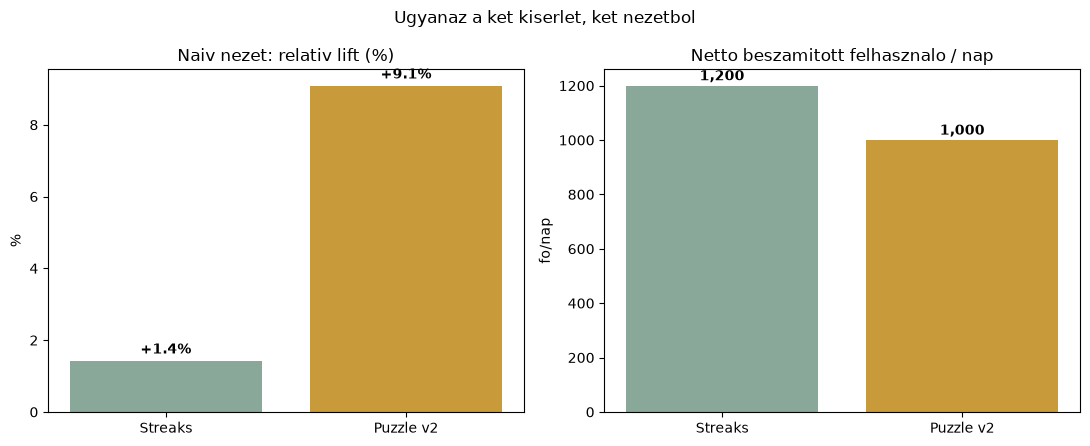

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(results_df["name"], results_df["relative_lift"] * 100, color=["#8aa89a", "#c99a3a"])
axes[0].set_title("Naiv nezet: relativ lift (%)")
axes[0].set_ylabel("%")
for i, v in enumerate(results_df["relative_lift"] * 100):
    axes[0].text(i, v + 0.2, f"+{v:.1f}%", ha="center", fontweight="bold")

axes[1].bar(results_df["name"], results_df["incremental_users_per_day"], color=["#8aa89a", "#c99a3a"])
axes[1].set_title("Netto beszamitott felhasznalo / nap")
axes[1].set_ylabel("fo/nap")
for i, v in enumerate(results_df["incremental_users_per_day"]):
    axes[1].text(i, v + 20, f"{v:,.0f}", ha="center", fontweight="bold")

fig.suptitle("Ugyanaz a ket kiserlet, ket nezetbol")
fig.tight_layout()
plt.show()

## Ti jöttök

Egy harmadik csapat lefuttatott egy **"Lecke-ajánló"** kísérletet az Oktatás
funkcióterületen: akik félbehagytak egy leckét, személyre szabott ajánlást
kapnak a folytatásra.

- Elért létszám (reach): **16 000** fő/nap (a teljes DAU 8%-a — az Oktatás
  funkció napi aktív használói)
- D30-visszatérés: control **35,0%** → treatment **37,5%**

Számoljátok ki (a fenti `net_conversions_per_dau` függvénnyel) ennek a
kísérletnek a nettó konverzió/DAU értékét, és illesszétek be a `results_df`
táblázatba a Streaks és a Puzzle v2 mellé. **Hova kerül a rangsorban?** Ha a
GameLeap vezetőségnek csak egyet engedélyeznétek országos kiterjesztésre a
három közül, melyiket választanátok — és miért pont azt?

In [6]:
# Ide írjátok a megoldást
